# 01 — Exploratory Data Analysis
Song Recommendation Project — CS 3262

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from preprocess import load_and_clean

sns.set_theme(style='whitegrid')
df = load_and_clean()
print(df.shape)
df.head()

(170, 12)


,Timestamp,user_id,gender,hometown,user_lang,song,artist,genre,song_lang,release_year,song_lang_list,user_lang_list
0,2025/08/28 1:15:19 PM EST,gaoz9,Male,City,English;Chinese,Fame is a gun,Addison Rae,Pop,English,2020+,[English],"[English, Chinese]"
1,2025/08/28 1:17:01 PM EST,tastebursttreat,Female,Suburban,English;Chinese,run for the hills,Tate McRae,Pop,English,2020+,[English],"[English, Chinese]"
2,2025/08/28 1:17:21 PM EST,educated fax turn leg deserted,Male,Suburban,English,Hard to Explain,The Strokes,Indie / Alternative,English,2000–2009,[English],[English]
3,2025/08/28 1:17:43 PM EST,cannon,Male,Suburban,English,The Nights,Avicii,Pop,English,2010–2019,[English],[English]
4,2025/08/28 1:18:54 PM EST,abiding,Female,Suburban,English,Rock that body,Black eyed peas,Electronic / Dance,English,2010–2019,[English],[English]


## Basic stats

In [2]:
print('Unique users:', df['user_id'].nunique())
print('Unique songs:', df['song'].nunique())
print('Unique artists:', df['artist'].nunique())
print('Unique genres:', df['genre'].nunique())
print()
print('Songs per user:')
print(df.groupby('user_id').size().describe())

Unique users: 116
Unique songs: 168
Unique artists: 150
Unique genres: 14

Songs per user:
count    116.000000
mean       1.465517
std        1.274711
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       10.000000
dtype: float64


## Genre distribution

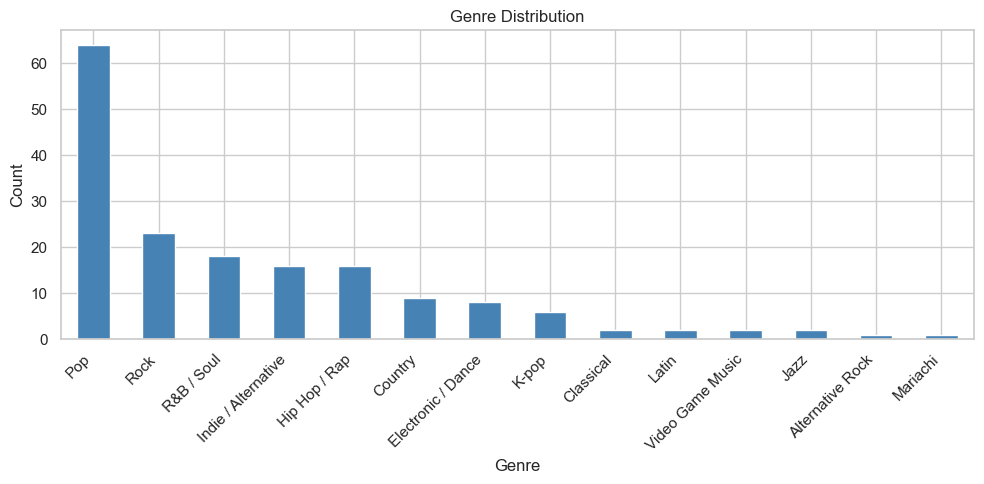

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
genre_counts = df['genre'].value_counts()
genre_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Genre Distribution')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Release year distribution

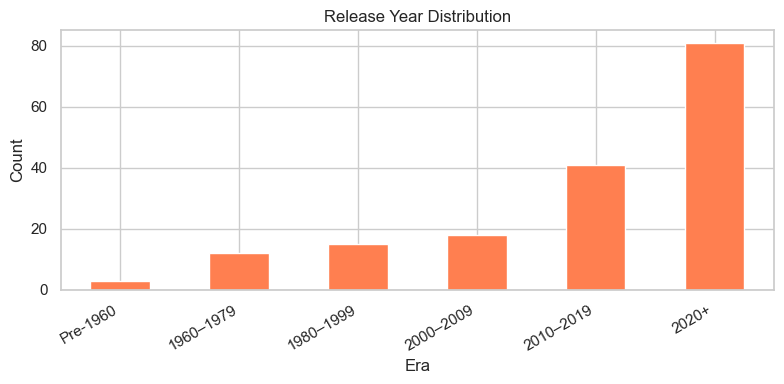

In [4]:
from preprocess import RELEASE_ORDER
fig, ax = plt.subplots(figsize=(8, 4))
year_counts = df['release_year'].value_counts().reindex(RELEASE_ORDER)
year_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Release Year Distribution')
ax.set_xlabel('Era')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Hometown × Genre heatmap

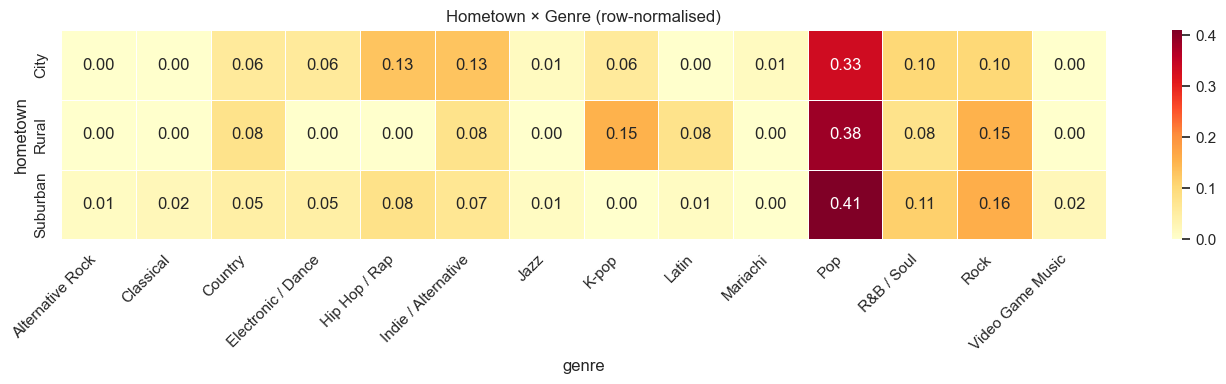

In [5]:
ct = pd.crosstab(df['hometown'], df['genre'], normalize='index')
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Hometown × Genre (row-normalised)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Gender × Genre heatmap

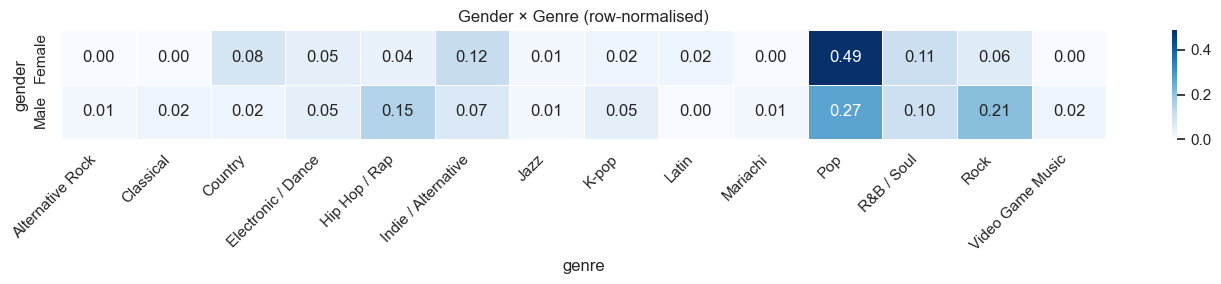

In [6]:
ct2 = pd.crosstab(df['gender'], df['genre'], normalize='index')
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(ct2, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Gender × Genre (row-normalised)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Top languages (user)

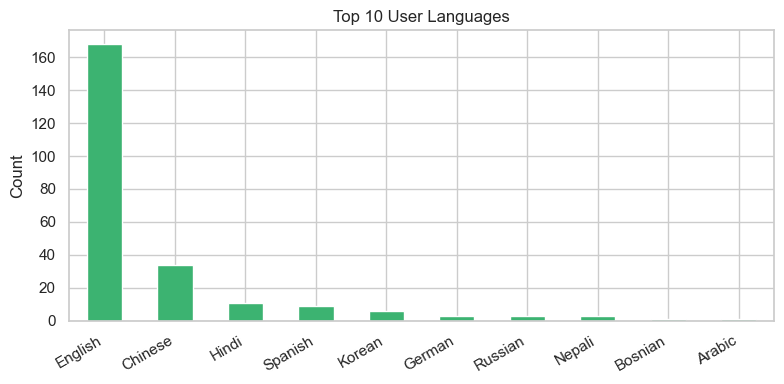

In [7]:
from collections import Counter
lang_counts = Counter(lang for langs in df['user_lang_list'] for lang in langs)
lang_df = pd.Series(lang_counts).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4))
lang_df.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Top 10 User Languages')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Top artists

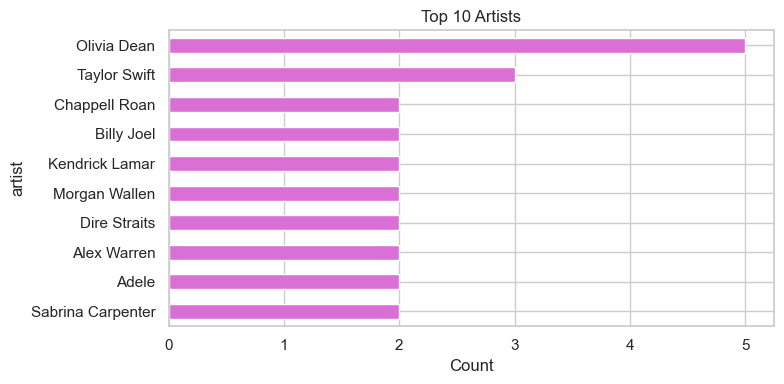

In [8]:
top_artists = df['artist'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
top_artists.plot(kind='barh', ax=ax, color='orchid', edgecolor='white')
ax.set_title('Top 10 Artists')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Observations
- Pop dominates (~37%), followed by Rock and R&B/Soul.
- Suburban users slightly favour Pop; City users show more diversity.
- ~47% of songs are from 2020+, reflecting a recency bias.
- ~99% of users speak English; Chinese and Hindi are the next most common.
- These patterns motivate using demographics to cluster/recommend music.